In [ ]:
!pip install tab-transformer-pytorch

In [3]:
import matplotlib as mpl
import matplotlib.pyplot as plt

!apt-get install -y fonts-nanum
!fc-cache -fv

mpl.font_manager._load_fontmanager(try_read_cache=False)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

Validation Accuracy: 0.7870
              precision    recall  f1-score   support

        Poor       0.77      0.81      0.79      5799
    Standard       0.82      0.78      0.80     10635
        Good       0.72      0.76      0.74      3566

    accuracy                           0.79     20000
   macro avg       0.77      0.79      0.78     20000
weighted avg       0.79      0.79      0.79     20000



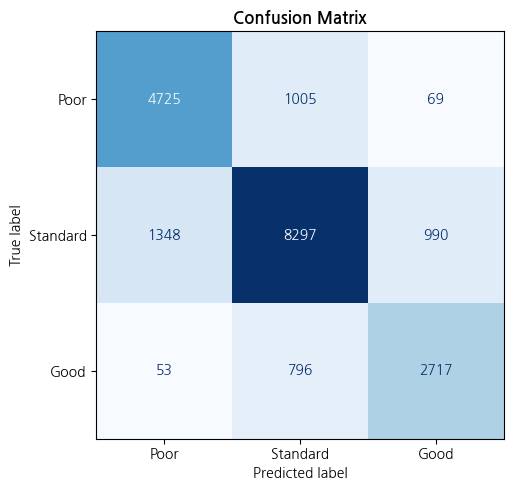

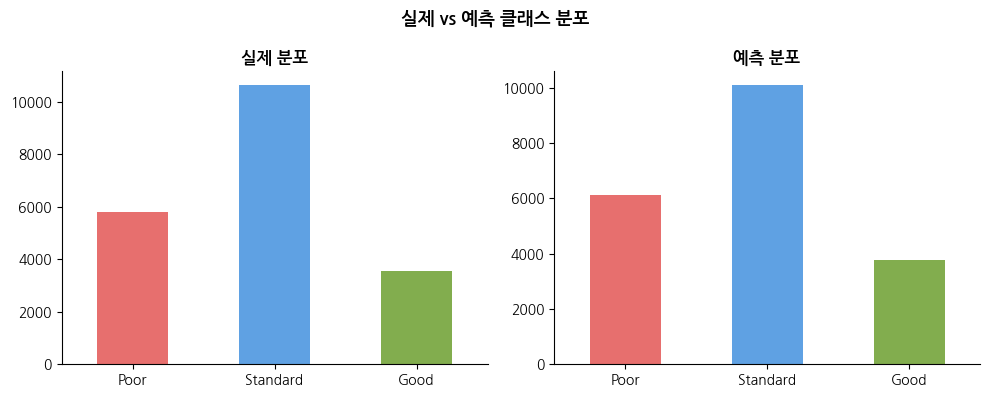

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tab_transformer_pytorch import TabTransformer

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── 데이터 로드 및 전처리 ──────────────────────────────
data = pd.read_csv('train_preprocessed.csv')
data.drop(columns=['Customer_ID', 'Month',
                   'Total_EMI_per_month', 'Credit_Utilization_Ratio'], inplace=True)

data['debt_to_income']    = data['Outstanding_Debt'] / data['Annual_Income']
data['delay_severity']    = data['Delay_from_due_date'] * data['Num_of_Delayed_Payment']
data['inquiry_per_card']  = data['Num_Credit_Inquiries'] / (data['Num_Credit_Card'] + 1)
data['balance_to_salary'] = data['Monthly_Balance'] / (data['Monthly_Inhand_Salary'] + 1)
data['loan_burden']       = data['Num_of_Loan'] * data['Interest_Rate']

data.drop(columns=['Outstanding_Debt', 'Delay_from_due_date', 'Num_of_Delayed_Payment',
                   'Num_Credit_Inquiries', 'Monthly_Balance', 'Num_of_Loan', 'Interest_Rate'], inplace=True)

cat_col_names = [
    'Occupation', 'Credit_Mix', 'Payment_of_Min_Amount',
    'spent_level', 'payment_size',
    'loan_auto_loan', 'loan_credit_builder_loan', 'loan_debt_consolidation_loan',
    'loan_home_equity_loan', 'loan_mortgage_loan', 'loan_payday_loan',
    'loan_personal_loan', 'loan_student_loan'
]
num_col_names = [c for c in data.columns if c not in cat_col_names + ['Credit_Score']]

X_cat = data[cat_col_names].values.astype(np.int64)
X_num = data[num_col_names].values.astype(np.float32)
y     = data['Credit_Score'].values.astype(np.int64)

X_cat_train, X_cat_valid, X_num_train, X_num_valid, y_train, y_valid = train_test_split(
    X_cat, X_num, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_num_train = scaler.fit_transform(X_num_train)
X_num_valid = scaler.transform(X_num_valid)

# ── DataLoader ─────────────────────────────────────────
def make_loader(X_cat, X_num, y, batch_size, shuffle=False):
    dataset = TensorDataset(
        torch.tensor(X_cat, dtype=torch.long),
        torch.tensor(X_num, dtype=torch.float32),
        torch.tensor(y,     dtype=torch.long)
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

valid_loader = make_loader(X_cat_valid, X_num_valid, y_valid, batch_size=512)

# ── 모델 로드 ──────────────────────────────────────────
cat_dims = [int(data[c].max()) + 1 for c in cat_col_names]

model = TabTransformer(
    categories=tuple(cat_dims),
    num_continuous=len(num_col_names),
    dim=32,
    depth=3,
    heads=4,
    attn_dropout=0.1,
    ff_dropout=0.1,
    mlp_hidden_mults=(4, 2),
    mlp_act=nn.GELU(),
    num_special_tokens=2,
    dim_out=3,
).to(device)

model.load_state_dict(torch.load('/content/tabtransformer_best.pt', map_location=device))
model.eval()

# ── 예측 ───────────────────────────────────────────────
preds_all, labels_all = [], []
with torch.no_grad():
    for x_cat, x_num, labels in valid_loader:
        x_cat, x_num = x_cat.to(device), x_num.to(device)
        outputs = model(x_cat, x_num)
        preds_all.extend(torch.argmax(outputs, dim=1).cpu().numpy())
        labels_all.extend(labels.numpy())

print(f"Validation Accuracy: {accuracy_score(labels_all, preds_all):.4f}")
print(classification_report(labels_all, preds_all, target_names=['Poor', 'Standard', 'Good']))

# ── Confusion Matrix ───────────────────────────────────
cm = confusion_matrix(labels_all, preds_all)
disp = ConfusionMatrixDisplay(cm, display_labels=['Poor', 'Standard', 'Good'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 실제 vs 예측 클래스 분포 ──────────────────────────
labels_name = ['Poor', 'Standard', 'Good']
colors = ['#E24B4A', '#378ADD', '#639922']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
pd.Series(labels_all).map({0:'Poor',1:'Standard',2:'Good'}).value_counts().reindex(labels_name).plot(
    kind='bar', ax=axes[0], color=colors, alpha=0.8, edgecolor='none')
axes[0].set_title('실제 분포', fontweight='bold')
axes[0].tick_params(axis='x', rotation=0)
axes[0].spines[['top','right']].set_visible(False)

pd.Series(preds_all).map({0:'Poor',1:'Standard',2:'Good'}).value_counts().reindex(labels_name).plot(
    kind='bar', ax=axes[1], color=colors, alpha=0.8, edgecolor='none')
axes[1].set_title('예측 분포', fontweight='bold')
axes[1].tick_params(axis='x', rotation=0)
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('실제 vs 예측 클래스 분포', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pred_distribution.png', dpi=150, bbox_inches='tight')
plt.show()